# Importation des bibliothéques

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Traitement préliminaire

In [ ]:
# Chargement de la base de données
df = pd.read_csv('Database_Project_L3_MAIE_MOSIEF.csv', sep=';', decimal=',', encoding='latin-1')

In [ ]:
# Conversion de la colonne date
df['Date Deboursement'] = pd.to_datetime(df['Date Deboursement'], format='%Y%m%d', errors='coerce')

# Aperçu des données
print("Aperçu des 5 premières lignes :")
df.head()

Aperçu des 5 premières lignes :


,ID,Age,Secteur,Sexe,Date Deboursement,Montant Deboursé,Montant Encours,Anciennete(Mois),Situation Matrimoniale,Niveau_Education,Zone,Type_Credit,Statut_Credit
0,273438,30,Service,Femme,2024-08-24,959994.75,961846.75,101,Célibataire,Secondaire,Urbain,Moyen Terme,A risque
1,155449,32,Education,Homme,2024-09-14,6410029.64,6412311.64,134,Célibataire,Secondaire,Urbain,Court Terme,A risque
2,243101,52,Education,Homme,2024-09-12,15385903.93,15389547.93,26,Célibataire,Secondaire,Urbain,Court Terme,A risque
3,287630,47,Education,Femme,2023-05-26,381375.70,384738.70,76,Marié(e),Superieur,Urbain,Moyen Terme,Sain
4,247184,51,Agriculture,Homme,2023-05-31,99562968.57,99567099.57,124,Autre,Secondaire,Urbain,Long terme,Sain


# PARTIE I – COMPRÉHENSION DES DONNÉES (Data Understanding)

### 1. Description des différentes variables disponibles

In [ ]:
# Type des variables
print("\nInfos sur les types de variables :")
df.info()


Infos sur les types de variables :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4446 entries, 0 to 4445
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID                      4446 non-null   int64         
 1   Age                     4446 non-null   int64         
 2   Secteur                 4446 non-null   object        
 3   Sexe                    4428 non-null   object        
 4   Date Deboursement       4446 non-null   datetime64[ns]
 5   Montant Deboursé        4446 non-null   float64       
 6   Montant Encours         4446 non-null   float64       
 7   Anciennete(Mois)        4446 non-null   int64         
 8   Situation Matrimoniale  4446 non-null   object        
 9   Niveau_Education        4446 non-null   object        
 10  Zone                    4446 non-null   object        
 11  Type_Credit             4446 non-null   object        
 12  Statut_Credi

### 2. Analyse des distributions

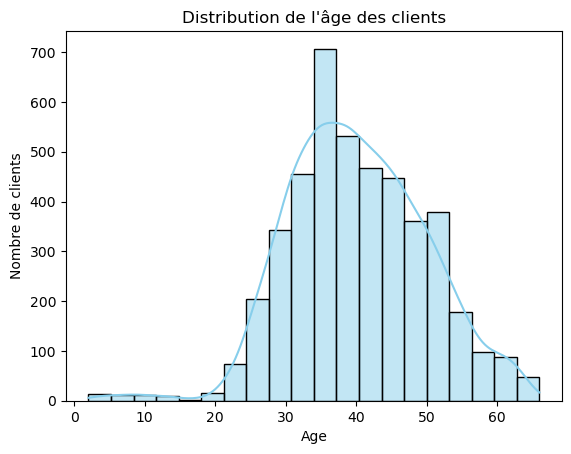

Statistiques Age :
count    4446.000000
mean       40.170940
std         9.748861
min         2.000000
25%        33.000000
50%        40.000000
75%        47.000000
max        66.000000
Name: Age, dtype: float64


In [ ]:
# Analyse de la distribution de l’âge des clients
sns.histplot(df['Age'], kde=True, bins=20, color='skyblue')
plt.title('Distribution de l\'âge des clients')
plt.xlabel('Age')
plt.ylabel('Nombre de clients')
plt.show()
# Commentaire à faire dans ton rapport : La population est-elle jeune ? Y a-t-il une concentration autour d'un âge précis ?
print("Statistiques Age :")
print(df['Age'].describe())

C:\Users\dell\AppData\Local\Temp\ipykernel_28732\2349400247.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Secteur', order=df['Secteur'].value_counts().index, palette='viridis')


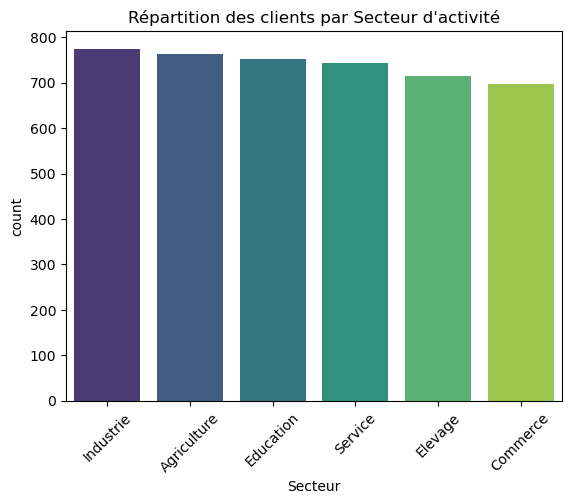

Statistiques Secteur :
count          4446
unique            6
top       Industrie
freq            775
Name: Secteur, dtype: object

--- Pourcentages par Secteur ---
Secteur
Industrie      17.431399
Agriculture    17.183986
Education      16.914080
Service        16.711651
Elevage        16.081871
Commerce       15.677013
Name: proportion, dtype: float64


In [ ]:
# Répartition des clients par Secteur d'activité
sns.countplot(data=df, x='Secteur', order=df['Secteur'].value_counts().index, palette='viridis')
plt.title('Répartition des clients par Secteur d\'activité')
plt.xticks(rotation=45)
plt.show()
#Statistique secteur d'activité
print("Statistiques Secteur :")
print(df['Secteur'].describe())
# Calcul des pourcentages exacts pour chaque secteur
# normalize=True transforme les nombres en proportions (entre 0 et 1)
# On multiplie par 100 pour avoir des pourcentages
pourcentages_secteur = df['Secteur'].value_counts(normalize=True) * 100

print("\n--- Pourcentages par Secteur ---")
print(pourcentages_secteur)

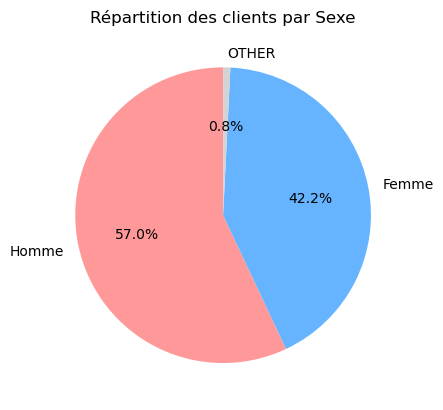

Statistiques Sexe :
count      4428
unique        3
top       Homme
freq       2524
Name: Sexe, dtype: object


In [ ]:
# Répartition par Sexe
df['Sexe'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff', '#D3D3D3'])
plt.title('Répartition des clients par Sexe')
plt.ylabel('')
plt.show()
#Statistique sexe
print("Statistiques Sexe :")
print(df['Sexe'].describe())

# PARTIE II - ANALYSE EXPLORATOIRE (EDA)

### 1. Calcul des statistiques descriptives des variables quantitatives

In [ ]:
cols_quantitatives = ['Age', 'Montant Deboursé', 'Montant Encours', 'Anciennete(Mois)']
print("--- Statistiques Descriptives ---")
print(df[cols_quantitatives].describe())

--- Statistiques Descriptives ---
               Age  Montant Deboursé  Montant Encours  Anciennete(Mois)
count  4446.000000      4.446000e+03     4.446000e+03       4446.000000
mean     40.170940      3.207264e+06     3.212817e+06         71.742690
std       9.748861      9.967165e+06     9.967046e+06         39.030436
min       2.000000      1.182772e+05     1.282462e+05          5.000000
25%      33.000000      4.445001e+05     4.488618e+05         38.000000
50%      40.000000      7.889516e+05     7.972641e+05         71.000000
75%      47.000000      1.921878e+06     1.923693e+06        105.000000
max      66.000000      1.866845e+08     1.866883e+08        140.000000


### 2. Relation entre Montant Deboursé et Montant Encours

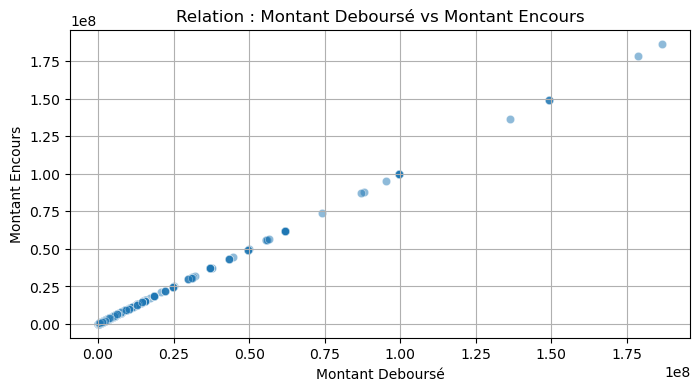

Coefficient de corrélation : 1.0000


In [ ]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='Montant Deboursé', y='Montant Encours', alpha=0.5)
plt.title('Relation : Montant Deboursé vs Montant Encours')
plt.grid(True)
plt.show()

# Calcul de la corrélation
corr = df['Montant Deboursé'].corr(df['Montant Encours'])
print(f"Coefficient de corrélation : {corr:.4f}")

### 3. Étude du Taux de remboursement selon le secteur d’activité

C:\Users\dell\AppData\Local\Temp\ipykernel_28732\2291322460.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Secteur', y='Taux_Remboursement', estimator='mean', errorbar=None, palette='magma')


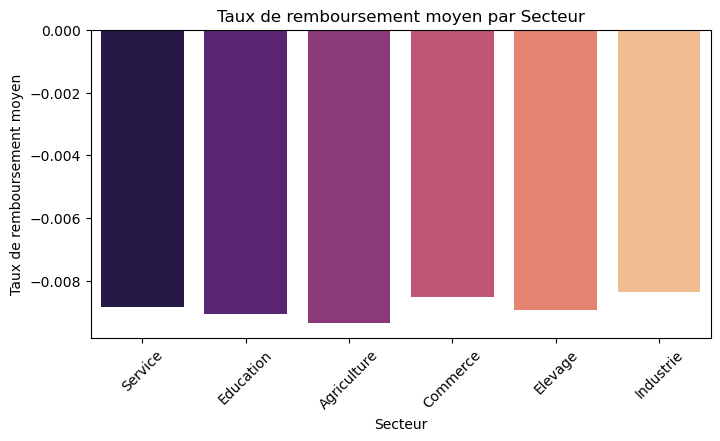


--- Stats du Taux de Remboursement ---
count    4446.000000
mean       -0.008836
std         0.009713
min        -0.084285
25%        -0.012162
50%        -0.005615
75%        -0.002098
max        -0.000013
Name: Taux_Remboursement, dtype: float64


In [ ]:
# Création de la variable 'Taux_Remboursement'
df['Taux_Remboursement'] = (df['Montant Deboursé'] - df['Montant Encours']) / df['Montant Deboursé']
# Graphique par secteur
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='Secteur', y='Taux_Remboursement', estimator='mean', errorbar=None, palette='magma')
plt.title('Taux de remboursement moyen par Secteur')
plt.ylabel('Taux de remboursement moyen')
plt.xticks(rotation=45)
plt.show()
# Affichage des stats du taux
print("\n--- Stats du Taux de Remboursement ---")
print(df['Taux_Remboursement'].describe())

### 4. Analyse de l’impact de l’âge du client sur le comportement de remboursement

C:\Users\dell\AppData\Local\Temp\ipykernel_28732\544787983.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Statut_Credit', y='Age', palette='Set2')


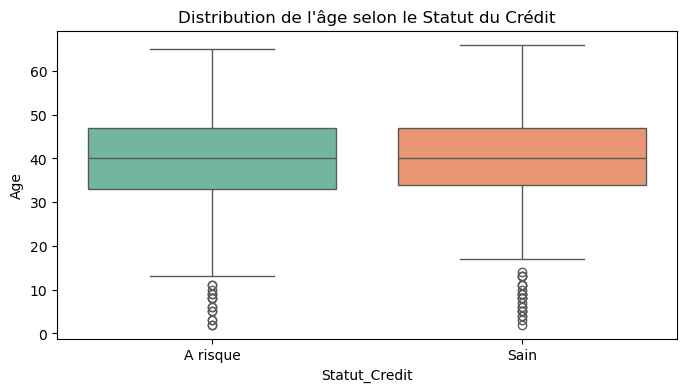

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Statut_Credit', y='Age', palette='Set2')
plt.title('Distribution de l\'âge selon le Statut du Crédit')
plt.show()

### 5. Identification et commentaire de la présence de valeurs aberrantes

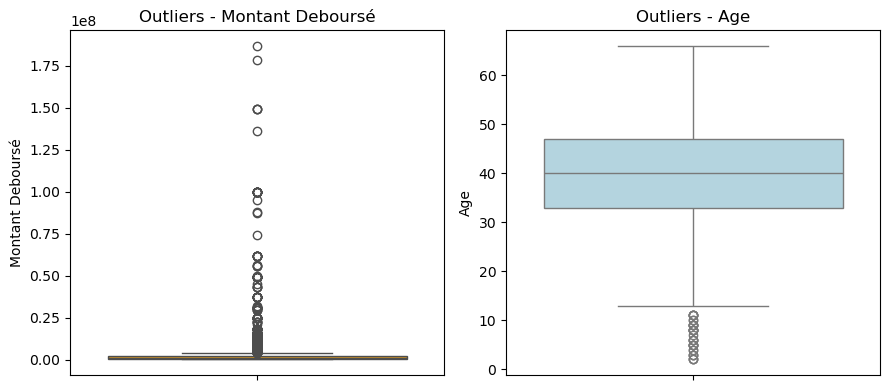

ANALYSE DES VALEURS ABBERRANTES
Age Minimum : 2 ans
Age Maximum : 66 ans
Nombre de clients mineurs (<18 ans) : 47

Seuil du Top 1% des montants : 49,462,981
Nombre de dossiers considérés comme 'Très Gros Montants' (VIP) : 45


In [ ]:
plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Montant Deboursé'], color='orange')
plt.title('Outliers - Montant Deboursé')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Age'], color='lightblue')
plt.title('Outliers - Age')

plt.tight_layout()
plt.show()

# ANALYSE CHIFFRÉE
print("ANALYSE DES VALEURS ABBERRANTES")

# Analyse des Âges
print(f"Age Minimum : {df['Age'].min()} ans")
print(f"Age Maximum : {df['Age'].max()} ans")
nb_mineurs = len(df[df['Age'] < 18])
print(f"Nombre de clients mineurs (<18 ans) : {nb_mineurs}")

# Analyse des Montants
montant_seuil = df['Montant Deboursé'].quantile(0.99)
nb_gros_montants = len(df[df['Montant Deboursé'] > montant_seuil])
print(f"\nSeuil du Top 1% des montants : {montant_seuil:,.0f}")
print(f"Nombre de dossiers considérés comme 'Très Gros Montants' (VIP) : {nb_gros_montants}")

# PARTIE III - PRÉTRAITEMENT & FEATURE ENGINEERING

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

### 1. Description des problèmes de qualités des données rencontrées

### Voir PDF

### 2. Méthode de traitement des valeurs manquantes

In [ ]:
# Suppression des mineurs (< 18 ans)
# On garde uniquement ceux qui ont >= 18 ans
df_clean = df[df['Age'] >= 18].copy()
nb_supprimes = len(df) - len(df_clean)
print(f"Lignes supprimées (Mineurs) : {nb_supprimes}")

# Traitement des valeurs manquantes pour le Sexe
# Au lieu de forcer "Homme", on les met dans "OTHER" (ou "Inconnu")
# Cela évite d'introduire un biais, car on ne connait pas leur vrai sexe.
df_clean['Sexe'] = df_clean['Sexe'].fillna('OTHER')

print(f"Les 18 valeurs manquantes de 'Sexe' ont été classées comme 'OTHER'.")
print("Nouvelle répartition Sexe :")
print(df_clean['Sexe'].value_counts())

Lignes supprimées (Mineurs) : 47
Les 18 valeurs manquantes de 'Sexe' ont été classées comme 'OTHER'.
Nouvelle répartition Sexe :
Sexe
Homme    2523
Femme    1869
OTHER       7
Name: count, dtype: int64


### 4. Proposition de nouvelles variables pertinentes pour l’analyse du risque crédit

In [ ]:
df_final = df_clean.copy()
# Variable 1 : Taux de Remboursement (déjà vue, mais on la formalise)
# Formule : (Déboursé - Encours) / Déboursé
df_final['Taux_Remboursement'] = (df_final['Montant Deboursé'] - df_final['Montant Encours']) / df_final['Montant Deboursé']

# Variable 2 : Mensualité Théorique
# L'idée est de voir combien le client a remboursé (ou doit rembourser) par mois en moyenne
# Formule : Montant Deboursé / Ancienneté
df_final['Mensualite_Theorique'] = df_final['Montant Deboursé'] / df_final['Anciennete(Mois)'].replace(0, 1)

# Variable 3 : Logarithme du Montant (Log_Montant)
df_final['Log_Montant'] = np.log1p(df_final['Montant Deboursé'])

### 3. Explication et application de la méthode d’Encodage des Variables Catégorielles

In [ ]:
# Variable Cible (Statut_Credit)
mapping_cible = {'A risque': 1, 'Sain': 0}
df_final['Statut_Credit_Encoded'] = df_final['Statut_Credit'].map(mapping_cible)

# Variables Explicatives (One-Hot Encoding)
cols_cat = [
    'Secteur',
    'Sexe',
    'Situation Matrimoniale',
    'Niveau_Education',
    'Zone',
    'Type_Credit'
]
# On encode et on remplace les anciennes colonnes texte par des chiffres (True/False ou 0/1)
df_final = pd.get_dummies(df_final, columns=cols_cat, drop_first=True, dtype=int)

### 5. Justification de la nécessité de la normalisation ou de la standardisation

In [ ]:
scaler = StandardScaler()
# Liste des colonnes à mettre à l'échelle
cols_num = [
    'Age',
    'Montant Deboursé',
    'Montant Encours',
    'Anciennete(Mois)',
    'Taux_Remboursement',
    'Mensualite_Theorique',
    'Log_Montant'
]

# On applique le scaler uniquement sur ces colonnes
df_final[cols_num] = scaler.fit_transform(df_final[cols_num])

# Vérification
print(f"Dimensions finales : {df_final.shape}")
print("\nAperçu des 5 premières lignes :")
display(df_final.head())

Dimensions finales : (4399, 25)

Aperçu des 5 premières lignes :


,ID,Age,Date Deboursement,Montant Deboursé,Montant Encours,Anciennete(Mois),Statut_Credit,Taux_Remboursement,Mensualite_Theorique,Log_Montant,...,Secteur_Service,Sexe_Homme,Sexe_OTHER,Situation Matrimoniale_Célibataire,Situation Matrimoniale_Marié(e),Niveau_Education_Secondaire,Niveau_Education_Superieur,Zone_Urbain,Type_Credit_Long terme,Type_Credit_Moyen Terme
0,273438,-1.139581,2024-08-24,-0.226579,-0.227019,0.748471,A risque,0.718819,-0.169105,-0.068240,...,1,0,0,1,0,1,0,1,0,1
1,155449,-0.922708,2024-09-14,0.417423,0.417041,1.594161,A risque,0.880548,-0.061988,1.512522,...,0,1,0,1,0,1,0,1,0,0
2,243101,1.246021,2024-09-12,1.478054,1.477846,-1.173550,A risque,0.892798,1.458043,2.241496,...,0,1,0,1,0,1,0,1,0,0
3,287630,0.703839,2023-05-26,-0.294951,-0.295214,0.107797,Sain,0.010612,-0.181644,-0.836805,...,0,0,0,0,1,0,1,1,0,1
4,247184,1.137585,2023-05-31,11.424808,11.424780,1.337891,Sain,0.912881,2.048141,3.796155,...,0,1,0,0,0,1,0,1,1,0


# PARTIE IV – CLUSTERING (SEGMENTATION CLIENTS) (OPTIONEL)

In [ ]:
from sklearn.cluster import KMeans

### Voir PDF pour question 1 et 2

### 3. Déterminer le nombre optimal de clusters (Méthode du Coude / Elbow Method)

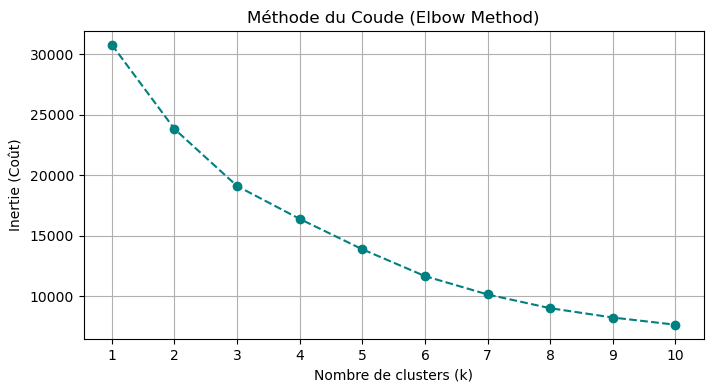

--- Profils des 3 Segments (Moyennes) ---
               Age  Montant Deboursé  Taux_Remboursement  Anciennete(Mois)
Cluster                                                                   
0        43.571740      4.579092e+06           -0.002436         71.701037
1        38.245843      5.376405e+05           -0.013767         71.843626
2        43.100000      7.266171e+07           -0.000075         72.875000


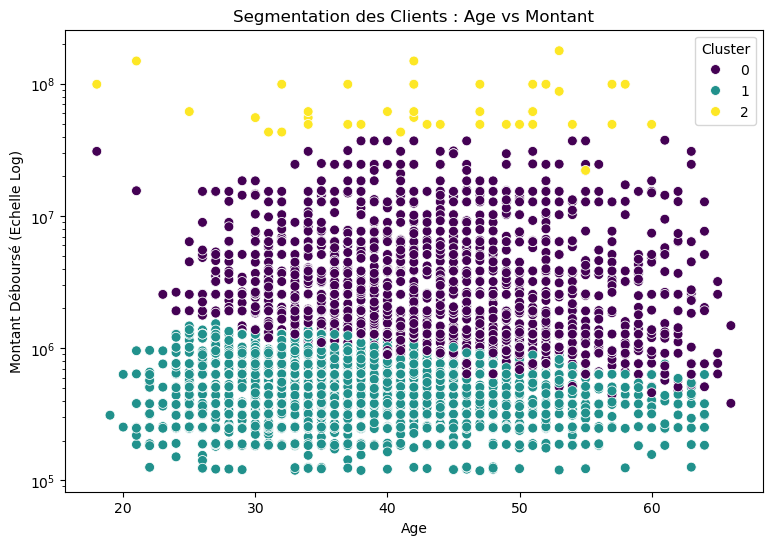

In [ ]:
# On utilise les données normalisées calculées en Partie III
cols_for_clustering = [
    'Age',
    'Montant Deboursé',
    'Montant Encours',
    'Anciennete(Mois)',
    'Taux_Remboursement',
    'Mensualite_Theorique',
    'Log_Montant'
]
X_scaled = df_final[cols_for_clustering]

# Méthode du Coude (Elbow Method)
inertia = []
range_clusters = range(1, 11) # On teste de 1 à 10 groupes
for k in range_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    
# Affichage du graphique
plt.figure(figsize=(8, 4))
plt.plot(range_clusters, inertia, marker='o', linestyle='--', color='teal')
plt.title('Méthode du Coude (Elbow Method)')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie (Coût)')
plt.xticks(range_clusters)
plt.grid(True)
plt.show()

# Interprétation visuelle
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

clusters = kmeans_final.fit_predict(X_scaled)
df_clean['Cluster'] = clusters
df_final['Cluster'] = clusters

# Analyse des résultats
print(f"--- Profils des {optimal_k} Segments (Moyennes) ---")
analysis = df_clean.groupby('Cluster')[['Age', 'Montant Deboursé', 'Taux_Remboursement', 'Anciennete(Mois)']].mean()
print(analysis)

# Visualisation 
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_clean, x='Age', y='Montant Deboursé', hue='Cluster', palette='viridis', s=50)
plt.title('Segmentation des Clients : Age vs Montant')
plt.yscale('log')
plt.ylabel('Montant Déboursé (Echelle Log)')
plt.show()

# PARTIE V – MACHINE LEARNING SUPERVISÉ (PRÉDICTION)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### 1. Définition de la Cible (y) et des Variables Explicatives (X) 

In [ ]:
#La cible est le statut du crédit 
y = df_final['Statut_Credit_Encoded'] 

# Les variables explicatives
cols_to_drop = ['Statut_Credit', 'Statut_Credit_Encoded', 'Montant Encours', 'Date Deboursement', 'Cluster', 'ID']
X = df_final.drop(columns=cols_to_drop, errors='ignore')

In [ ]:
# On garde 80% des données pour apprendre (Train) et 20% pour tester (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Données d'entraînement : {X_train.shape}")
print(f"Données de test : {X_test.shape}")

Données d'entraînement : (3519, 20)
Données de test : (880, 20)


### 3. Implémentation et comparaison de deux algorithmes de classification

In [ ]:
# Modèle 1 : Régression Logistique
print("\nModèle 1 : Régression Logistique")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

# Évaluation
print("Précision (Accuracy) :", accuracy_score(y_test, y_pred_log))
print("\nMatrice de Confusion (LogReg) :")
print(confusion_matrix(y_test, y_pred_log))
print("\nRapport de Classification :")
print(classification_report(y_test, y_pred_log))

# Modèle 2 : Random Forest
print("\nModèle 2 : Random Forest")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Évaluation
print("Précision (Accuracy) :", accuracy_score(y_test, y_pred_rf))
print("\nMatrice de Confusion (Random Forest) :")
print(confusion_matrix(y_test, y_pred_rf))
print("\nRapport de Classification :")
print(classification_report(y_test, y_pred_rf))


Modèle 1 : Régression Logistique
Précision (Accuracy) : 0.5056818181818182

Matrice de Confusion (LogReg) :
[[180 266]
 [169 265]]

Rapport de Classification :
              precision    recall  f1-score   support

           0       0.52      0.40      0.45       446
           1       0.50      0.61      0.55       434

    accuracy                           0.51       880
   macro avg       0.51      0.51      0.50       880
weighted avg       0.51      0.51      0.50       880


Modèle 2 : Random Forest
Précision (Accuracy) : 0.5034090909090909

Matrice de Confusion (Random Forest) :
[[213 233]
 [204 230]]

Rapport de Classification :
              precision    recall  f1-score   support

           0       0.51      0.48      0.49       446
           1       0.50      0.53      0.51       434

    accuracy                           0.50       880
   macro avg       0.50      0.50      0.50       880
weighted avg       0.50      0.50      0.50       880



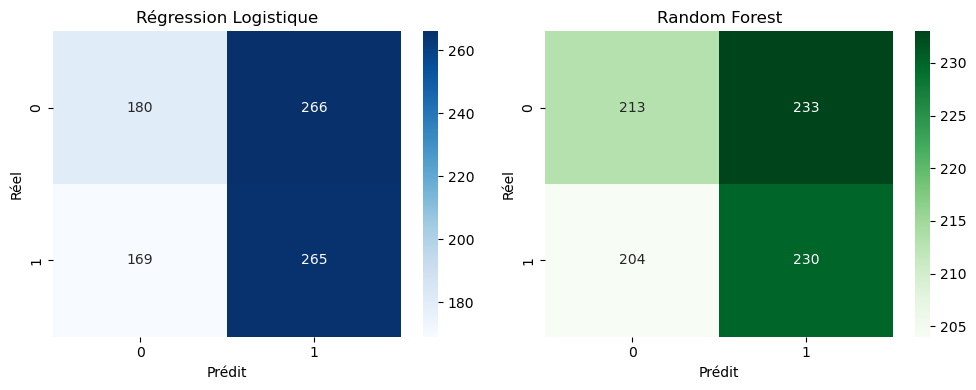

In [ ]:
# Comparaison Visuelle des Matrices de Confusion 
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title('Régression Logistique')
plt.xlabel('Prédit')
plt.ylabel('Réel')


plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest')
plt.xlabel('Prédit')
plt.ylabel('Réel')

plt.tight_layout()
plt.show()

### 6. Interprétation des résultats obtenus du point de vue du risque crédit

In [ ]:
feature_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 5 des variables les plus importantes :")
print(feature_imp.head(5))


Top 5 des variables les plus importantes :
Taux_Remboursement      0.136644
Mensualite_Theorique    0.133837
Log_Montant             0.129558
Montant Deboursé        0.126556
Anciennete(Mois)        0.126015
dtype: float64


C:\Users\dell\AppData\Local\Temp\ipykernel_28732\3696255169.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_imp.head(10), y=feature_imp.head(10).index, palette='viridis')


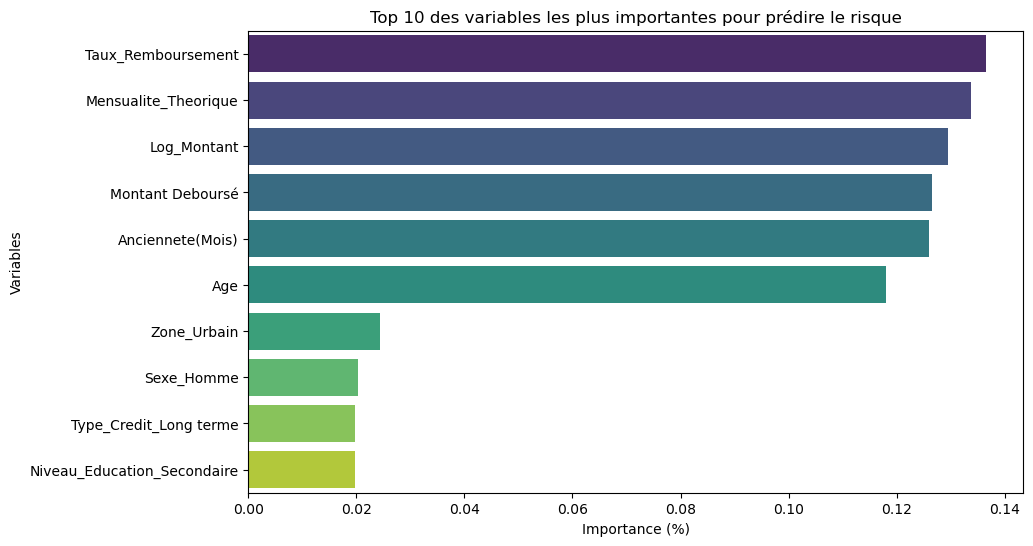


Top 10 des variables clés :
Taux_Remboursement             0.136644
Mensualite_Theorique           0.133837
Log_Montant                    0.129558
Montant Deboursé               0.126556
Anciennete(Mois)               0.126015
Age                            0.118049
Zone_Urbain                    0.024303
Sexe_Homme                     0.020374
Type_Credit_Long terme         0.019775
Niveau_Education_Secondaire    0.019771
dtype: float64


In [ ]:
feature_imp = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

# Affichage Graphique (Top 10)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_imp.head(10), y=feature_imp.head(10).index, palette='viridis')
plt.title('Top 10 des variables les plus importantes pour prédire le risque')
plt.xlabel('Importance (%)')
plt.ylabel('Variables')
plt.show()

print("\nTop 10 des variables clés :")
print(feature_imp.head(10))